# Permutation-Based Inference in R

## Overview

Permutation tests (randomization tests) are a broad class of inference procedures that build a null distribution by repeatedly shuffling the data. They make **no parametric distributional assumptions** — the null distribution is generated empirically from the data itself.

**The core idea:**
1. Compute a test statistic T from the observed data
2. Repeatedly shuffle the group labels (or the response values) and recompute T
3. The p-value = proportion of permuted T values ≥ observed T

**When to use permutation tests:**
- You want to test a custom statistic with no known parametric distribution
- Sample size is too small for asymptotic approximations
- Data clearly violate parametric assumptions and no transformation helps
- You want to avoid any distributional assumption and let the data speak
- You are analyzing multivariate data (PERMANOVA, Mantel test — already covered)

**Permutation vs. bootstrap:**  
Permutation tests assess significance under a specific null hypothesis (e.g., no group difference). Bootstrap estimates confidence intervals and sampling variability without a specific null. They answer different questions and are complementary.

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(coin)        # framework for permutation tests with complex designs
library(perm)        # permTS() — two-sample permutation t-test

set.seed(42)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'coin' was built under R version 4.4.3"
Loading required package: survival

Warning message:
"package 'surv

---

## From Scratch: Building Intuition

The best way to understand permutation tests is to write one from scratch before using packaged implementations.

Observed mean difference: 6.000
Permutation p-value (two-sided): 0.0014
Parametric t-test p-value:       0.0018


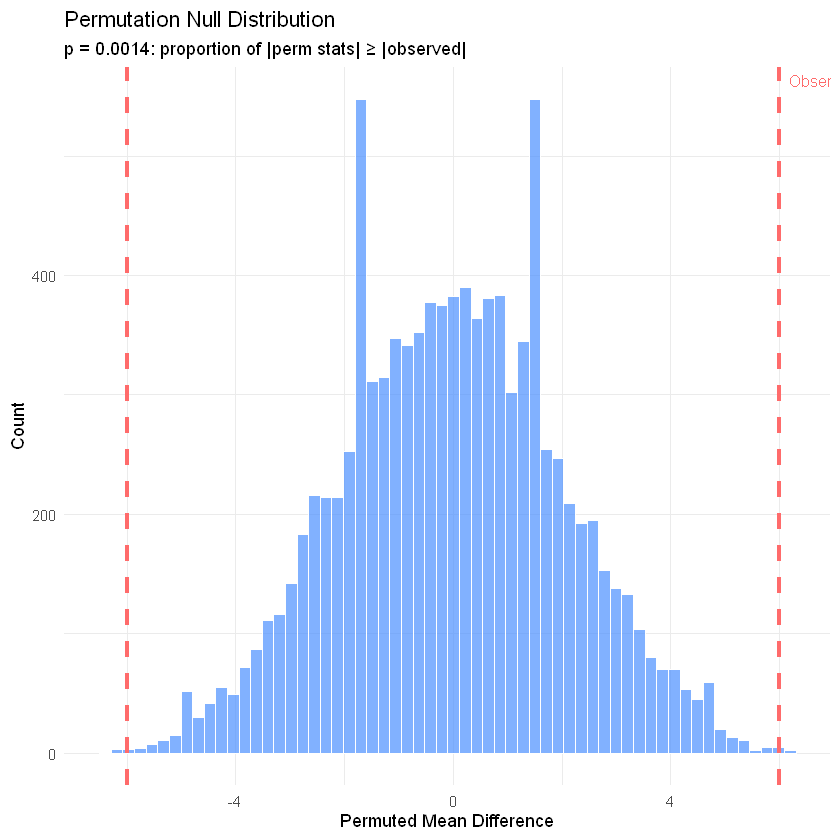

In [2]:
# ── Data: two independent groups ─────────────────────────────────────────────
group_a <- c(12, 9, 15, 18, 11, 14, 22, 8, 17, 13)
group_b <- c(7,  4, 11,  9,  6,  8, 12, 5, 10,  7)

# ── Observed test statistic: difference in means ──────────────────────────────
obs_stat <- mean(group_a) - mean(group_b)
cat(sprintf("Observed mean difference: %.3f\n", obs_stat))

# ── Permutation procedure ─────────────────────────────────────────────────────
n_perm  <- 9999
all_obs <- c(group_a, group_b)
n_a     <- length(group_a)

perm_stats <- replicate(n_perm, {
  shuffled <- sample(all_obs)          # shuffle all labels
  mean(shuffled[1:n_a]) - mean(shuffled[(n_a + 1):length(all_obs)])
})

# ── Permutation p-value (two-sided) ──────────────────────────────────────────
p_perm <- mean(abs(perm_stats) >= abs(obs_stat))
cat(sprintf("Permutation p-value (two-sided): %.4f\n", p_perm))
cat(sprintf("Parametric t-test p-value:       %.4f\n",
            t.test(group_a, group_b)$p.value))
# Should be similar for well-behaved data

# ── Visualize the null distribution ──────────────────────────────────────────
ggplot(tibble(stat = perm_stats), aes(x = stat)) +
  geom_histogram(bins = 60, fill = "#4a8fff", alpha = 0.7, color = "white") +
  geom_vline(xintercept = c(obs_stat, -obs_stat),
             color = "#ff6b6b", linewidth = 1.2, linetype = "dashed") +
  annotate("text", x = obs_stat, y = Inf,
           label = sprintf("  Observed = %.2f", obs_stat),
           vjust = 1.5, hjust = 0, color = "#ff6b6b", size = 3.5) +
  labs(
    title    = "Permutation Null Distribution",
    subtitle = sprintf("p = %.4f: proportion of |perm stats| ≥ |observed|", p_perm),
    x        = "Permuted Mean Difference",
    y        = "Count"
  ) +
  theme_minimal()

---

## Custom Test Statistics

The real power of permutation tests: any statistic can be tested, even those with no known null distribution.

In [3]:
# ── Simulate ecological data ──────────────────────────────────────────────────
n <- 40
eco_data <- tibble(
  habitat  = rep(c("reference", "degraded"), each = n/2),
  richness = c(MASS::rnegbin(n/2, mu=15, theta=2),
               MASS::rnegbin(n/2, mu=8,  theta=2))
)

# ── Test statistic 1: difference in medians ───────────────────────────────────
obs_med_diff <- with(eco_data,
  median(richness[habitat=="reference"]) -
  median(richness[habitat=="degraded"]))

perm_med <- replicate(9999, {
  perm <- eco_data %>% mutate(habitat = sample(habitat))
  with(perm,
    median(richness[habitat=="reference"]) -
    median(richness[habitat=="degraded"]))
})
p_med <- mean(abs(perm_med) >= abs(obs_med_diff))
cat(sprintf("Permutation test: median difference = %.1f, p = %.4f\n",
            obs_med_diff, p_med))

# ── Test statistic 2: ratio of variances ─────────────────────────────────────
# (no simple parametric null distribution for this)
obs_var_ratio <- with(eco_data,
  var(richness[habitat=="reference"]) /
  var(richness[habitat=="degraded"]))

perm_var <- replicate(9999, {
  perm <- eco_data %>% mutate(habitat = sample(habitat))
  with(perm,
    var(richness[habitat=="reference"]) /
    var(richness[habitat=="degraded"]))
})
p_var <- mean(perm_var >= obs_var_ratio | perm_var <= 1/obs_var_ratio)
cat(sprintf("Permutation test: variance ratio = %.3f, p = %.4f\n",
            obs_var_ratio, p_var))

Permutation test: median difference = 4.5, p = 0.0605
Permutation test: variance ratio = 5.550, p = 0.0452


---

## Using the `coin` Package

`coin` provides a rigorous framework for permutation tests with exact, asymptotic, and Monte Carlo approximations.

In [4]:
# ── Two-sample permutation test via coin ─────────────────────────────────────
coin_test <- coin::oneway_test(
  richness ~ factor(habitat),
  data         = eco_data,
  distribution = coin::approximate(nresample = 9999)  # Monte Carlo
  # distribution = "exact"       # exact for small n
  # distribution = "asymptotic"  # fast approximation for large n
)
print(coin_test)

# ── Permutation Wilcoxon via coin (exact p-value with ties) ───────────────────
coin_wilcox <- coin::wilcox_test(
  richness ~ factor(habitat),
  data         = eco_data,
  distribution = coin::approximate(nresample = 9999)
)
print(coin_wilcox)

# ── Permutation correlation test ──────────────────────────────────────────────
env_data <- eco_data %>%
  mutate(pH = 5 + 0.2 * richness + rnorm(n, 0, 0.5))

coin_corr <- coin::spearman_test(
  richness ~ pH,
  data         = env_data,
  distribution = coin::approximate(nresample = 9999)
)
print(coin_corr)


	Approximative Two-Sample Fisher-Pitman Permutation Test

data:  richness by factor(habitat) (degraded, reference)
Z = -2.6248, p-value = 0.0043
alternative hypothesis: true mu is not equal to 0


	Approximative Wilcoxon-Mann-Whitney Test

data:  richness by factor(habitat) (degraded, reference)
Z = -2.8751, p-value = 0.0023
alternative hypothesis: true mu is not equal to 0


	Approximative Spearman Correlation Test

data:  richness by pH
Z = 5.8943, p-value < 1e-04
alternative hypothesis: true rho is not equal to 0



---

## Permutation Test for Regression Coefficients

Observed slope: 0.6274
Permutation p:  0.0000
Parametric t p: 0.0000


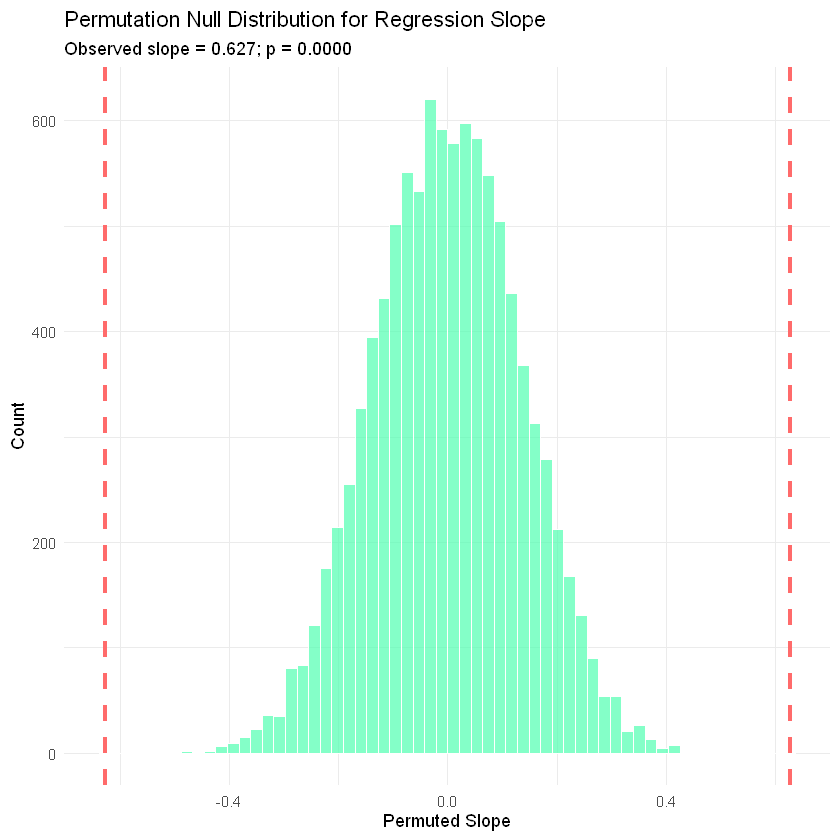

In [5]:
# ── Observed regression slope ─────────────────────────────────────────────────
n_reg <- 50
reg_data <- tibble(
  x = runif(n_reg, 0, 10),
  y = 2 + 0.8 * x + rnorm(n_reg, 0, 2)
)

obs_slope <- coef(lm(y ~ x, data = reg_data))["x"]

# ── Permute y to break x-y association ───────────────────────────────────────
perm_slopes <- replicate(9999, {
  coef(lm(sample(y) ~ x, data = reg_data))["x"]
})

p_slope <- mean(abs(perm_slopes) >= abs(obs_slope))

# ── Compare to parametric ─────────────────────────────────────────────────────
lm_p <- summary(lm(y ~ x, data = reg_data))$coefficients["x", "Pr(>|t|)"]

cat(sprintf("Observed slope: %.4f\n", obs_slope))
cat(sprintf("Permutation p:  %.4f\n", p_slope))
cat(sprintf("Parametric t p: %.4f\n", lm_p))

# ── Visualize ─────────────────────────────────────────────────────────────────
ggplot(tibble(slope = perm_slopes), aes(x = slope)) +
  geom_histogram(bins = 60, fill = "#4fffb0", alpha = 0.7, color = "white") +
  geom_vline(xintercept = c(obs_slope, -obs_slope),
             color = "#ff6b6b", linewidth = 1.2, linetype = "dashed") +
  labs(
    title    = "Permutation Null Distribution for Regression Slope",
    subtitle = sprintf("Observed slope = %.3f; p = %.4f", obs_slope, p_slope),
    x = "Permuted Slope", y = "Count"
  ) +
  theme_minimal()

---

## Reporting Results

In [6]:
# Standard reporting format:
# "We used a permutation test (9,999 random permutations) to assess
#  whether mean invertebrate richness differed between habitat types,
#  as the small sample size precluded reliable use of parametric tests.
#  Reference sites had significantly higher median richness than degraded
#  sites (observed median difference = XX.X; permutation p = .XXX)."
#
# "A permutation test of the regression slope was conducted to avoid
#  assumptions about residual normality (9,999 permutations of the
#  response variable). The slope was significantly positive
#  (β = X.XX, permutation p = .XXX), consistent with the parametric
#  result (p = .XXX)."
#
# Always report:
# - The test statistic used
# - The number of permutations
# - The exact permutation p-value (not just < 0.05)
# - Rationale for using permutation over parametric test
cat("Reporting guidance printed above.\n")

Reporting guidance printed above.


---

## Common Pitfalls

**1. Permuting the wrong quantity**  
For a two-sample test, permute the group labels (not the response values). For a regression slope, permute the response values (not the predictor). The correct permutation scheme depends on what the null hypothesis is.

**2. Using too few permutations**  
999 permutations is the absolute minimum; the smallest achievable p-value is 1/(n_perm + 1) = 0.001. For publication, use 9,999 or 99,999 permutations, especially when p is near the decision threshold.

**3. Treating permutation p-values as exact when they are approximate**  
Monte Carlo permutation p-values are random — they will vary slightly between runs. Set a seed for reproducibility and report the number of permutations.

**4. Confusing permutation tests with bootstrap confidence intervals**  
Permutation tests assess significance under H₀ by shuffling labels. Bootstrap estimates variability and constructs CIs by resampling with replacement. They are not interchangeable.

**5. Using permutation tests as an excuse to avoid model checking**  
Permutation tests are assumption-free about the null distribution — but they still require that observations are exchangeable under H₀. This fails with clustered, temporal, or spatial dependence. Use restricted permutations (e.g., `coin` or `permute` package) when samples are not freely interchangeable.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*